LLM Init

In [1]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM
#from chroma_db import db
import torch

print(torch.cuda.is_available())

c:\Users\Admin\source\repos\LLM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True


In [2]:
model_id = "Qwen/Qwen3.5-0.8B"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 320/320 [00:01<00:00, 182.48it/s]


DB Init

In [167]:
Chroma(
    collection_name="grants",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
).delete_collection()

In [168]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

import re
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict

PATH = "data/processed/eu_grants_norm.jsonl"

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

db = Chroma(collection_name="grants", embedding_function=embeddings, persist_directory="./chroma_db")

def ingest():
    stats = defaultdict(list)
    with open(PATH, "r", encoding="utf-8") as file:
        for line in tqdm(file, desc="Loading grants"):
            item = json.loads(line)
            text = item.get("embedding_text", "")
            # cut header
            idx_summary = text.find("Summary:")
            idx_keywords = text.find("Keywords:")
            idx_domains = text.find("Domains:")
            idx_fields = text.find("Fields:")

            title = text[len("Title:"):idx_summary]
            summary = text[idx_summary + len("Summary:\n")+3:idx_keywords]
            #print("T:", title)
            #print("S:", summary)
            # filter kw
            keywords = text[idx_keywords + len("Keywords:"):idx_domains].strip()
            keywords_list = [k.strip() for k in keywords.split(",")]
            filtered_keywords = [
                k for k in keywords_list
                if not is_code_like(k)]

            keywords = ", ".join(filtered_keywords)
            # build header
            header = build_grant_header(title, summary, keywords)
            # llm summary if needed
            if len(header) > 750:
                header = llm_summary(summary)
            #print(header)
            
            # cut chunks
            body = text[idx_fields + len("Fields:"):].strip()
            body_chunks = splitter.split_text(body)
            chunks = [
                header + "\n\nFields: " + chunk#
                for chunk in body_chunks
            ]
            
            # metadata
            metadata = {
                "id": item.get('id'),
                "source": item.get("source"),
                "status": item.get("status"),
                "start_date": item.get("start_date"),
                "end_date": item.get("end_date"),
                "min_amount": item.get("min_amount"),
                "max_amount": item.get("max_amount"),
                "url": item.get("url")
            }

            # metadata for every chunk
            metadatas = [metadata for _ in chunks]
            # unique ids for chunks
            ids = [
                f"{item.get('id')}_chunk_{i}"
                for i in range(len(chunks))
            ]
            # collect stats
            for i, ch in zip(ids, chunks):
                doc_id = int(i.rsplit("_", 1)[1])
                stats[doc_id].append(len(ch))

            # add chunks to chroma
            db.add_texts(
                texts=chunks,
                metadatas=metadatas,
                ids=ids
            )

    print(len(stats),len(stats[0]),len(stats[1]),len(stats[2]))
    plot_chunk_len(stats)
    print("Done.")

def is_code_like(text):
    return bool(re.fullmatch(r"[A-Z0-9\-]{8,}", text))

def llm_summary(text: str) -> str:
    messages = [
        {
            "role": "system",
            "content": (
                "You are a structured information extraction engine for retrieval systems. "
                "Your task is to rewrite input into a SINGLE formatted line.\n\n"
                "RULES:\n"
                "- Output ONLY one line\n"
                "- No explanations, no reasoning, no extra text\n"
                "- No markdown\n"
                "- Do NOT repeat input text\n"
                "- If keywords are missing, output empty string after Keywords:\n"
                "- Keep summary 3–6 sentences, factual and neutral\n"
                "- Maximum length: 1000 characters total"
                "Always follow exact format:\n"
                "Title: <title>\n"
                "Summary: <summary>\n"
                "Keywords: <keywords>\n"
            )
        },
        {
            "role": "user",
            "content": text
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=180,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )

    gen_tokens = outputs[0][inputs.input_ids.shape[1]:]

    result = tokenizer.decode(gen_tokens, skip_special_tokens=True)

    return result.strip()

def build_grant_header(title, summary, keywords):
    header = f"""Title: {title} \nSummary: {summary}"""

    if keywords:
       header += f"\nKeywords: {keywords}"

    return header

def plot_chunk_len(data):

    plt.boxplot(list(data.values()), labels=list(data.keys()),
        flierprops=dict(
        marker='.',
        markersize=3,
        markerfacecolor='red',
        markeredgecolor='red'))

    plt.xticks(rotation=45)
    plt.title("Chunk length per document")
    plt.ylabel("length")
    plt.show()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12877.08it/s]


In [169]:
data = db.get()

for doc, meta, id_ in zip(
    data["documents"],
    data["metadatas"],
    data["ids"]
):
    if id_.startswith("HORIZON-CL6-2027-01-ZEROPOLLUTION-02"):#HORIZON-CL6-2027-01-ZEROPOLLUTION-02
        print("\n", id_)
        print(doc)

Loading grants: 1586it [01:53, 13.95it/s]
C:\Users\Admin\AppData\Local\Temp\ipykernel_7952\638452030.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list(data.values()), labels=list(data.keys()),


31 1586 674 674


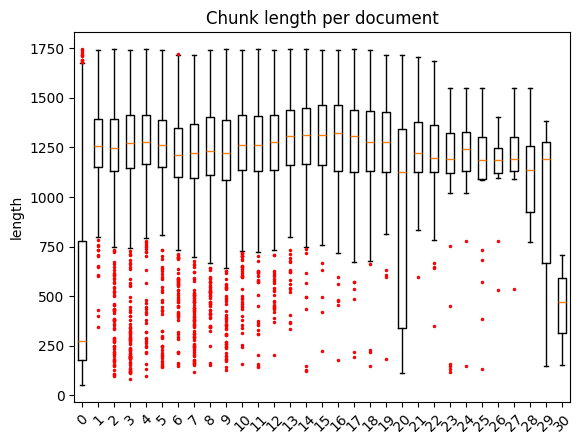

Done.


In [170]:
ingest()

Retrieval Pipeline

In [171]:
# retriever
retriever = db.as_retriever(search_type="mmr", search_kwargs={"k": 10, "fetch_k": 20})

In [172]:
print(next(model.parameters()).device)

cuda:0


In [258]:
def llm_expand_query(query: str) -> str:
    """
    Expands a short user query into a grant-search optimized query.
    """

    messages = [
    {
        "role": "system",
        "content": (
            "You are a query expansion engine for a Retrieval-Augmented Generation (RAG) system focused on EU research and innovation grants.\n"
            "\n"
            "Your task is to convert a short user query into a retrieval-optimized search query for a chunked vector database.\n"
            "\n"
            "DATABASE CONTEXT:\n"
            "- EU funding programs (Horizon Europe, ERC, Marie Skłodowska-Curie, national research grants)\n"
            "- grant calls, eligibility rules, deadlines, funding schemes\n"
            "- short text chunks with partial information\n"
            "\n"
            "CRITICAL RULES:\n"
            "- Output ONLY ONE single search query\n"
            "- Do NOT output full sentences\n"
            "- Do NOT write explanations or formatting\n"
            "- Do NOT include punctuation-heavy natural language\n"
            "- Do NOT hallucinate real grant facts\n"
            "- Do NOT repeat the same meaning in different words\n"
            "\n"
            "QUERY FORMAT REQUIREMENTS:\n"
            "- Must be keyword-dense (NOT sentence-style)\n"
            "- Prefer short noun phrases\n"
            "- Use comma or space separated terms only\n"
            "- Include synonyms only if they add new retrieval signals\n"
            "\n"
            "EXPANSION STRATEGY:\n"
            "- Add semantic synonyms: funding, grant, research funding, EU funding, call for proposals\n"
            "- Map concepts into EU research terminology (Horizon Europe, ERC, academic research)\n"
            "- Expand domain scope (academic, innovation, scientific research)\n"
            "- Include eligibility/funding context only as keywords (no sentences)\n"
            "\n"
            "GOAL:\n"
            "Maximize embedding recall and chunk overlap relevance in vector search."
        )
    },
    {
        "role": "user",
        "content": f"""
Original query:
{query}

Expanded query:
"""
    }
]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )

    result = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

    return result.strip()

In [259]:
llm_expand_query("Funding opportunities for Climate change research")#Economics and Governance

'funding opportunities climate change research EU Horizon Europe ERC call for proposals academic innovation'

In [273]:
def rag_answer(query: str):
    # 0 expansion
    expanded_query = llm_expand_query(query)

    # 1. RETRIEVE
    #results = db.similarity_search(expanded_query, k=5)
    results = retriever.invoke(expanded_query)

    unique_results = []
    grouped = {}

    for doc in results:
        doc_id = doc.metadata.get("id")
        text = doc.page_content

        if doc_id not in grouped:
            # создаём новый документ-контейнер
            grouped[doc_id] = doc
        else:
            # дописываем контент к уже существующему
            grouped[doc_id].page_content += "\n\n" + text[text.find("Fields:") + len("Fields:"):]

    results = list(grouped.values())

    if not results:
        return {
            "answer": "Insufficient evidence.",
            "sources": []
        }

    # 2. PACK CONTEXT
    context_chunks = []
    sources = []

    for i in range(len(results)):
        text = results[i].page_content
        context_chunks.append(f"[{i+1}]  {text}")
        context_chunks.append("start_date: " + str(results[i].metadata.get("start_date")))
        context_chunks.append("end_date: " + str(results[i].metadata.get("end_date")))
        context_chunks.append("min_amount: " + str(results[i].metadata.get("min_amount")))
        context_chunks.append("max_amount: " + str(results[i].metadata.get("max_amount")))
        if meta.get("source"):
            sources.append(results[i].metadata.get("url"))

    context = "\n\n".join(context_chunks)

    # 3. PROMPT
    prompt = f"""
You are a RAG assistant for grant-related questions.

RULES:
- Use ONLY provided context. No external knowledge.
- Do NOT hallucinate or guess missing information.
- EVERY FACTUAL CLAIM must be supported by context and cited [source].
- If information is missing or insufficient, say:
  "Insufficient evidence"

TASKS:

1. Retrieval / Extraction:
Extract relevant grant info strictly from context with citations.

2. Paraphrased queries:
Understand intent but answer ONLY from retrieved data.

3. Structured listing:
Return:
- Grant name
- Short description
- Funding
- Deadline
- [source] citarion
If missing → "Not specified in sources"

4. Filtering:
Strictly filter by attributes using only context.

5. Comparison:
Use tables. No missing-data guessing.

6. Source verification:
Only confirm if explicitly supported by text.

7. Multi-turn:
Respect prior context and constraints.

8. Abstention:
If unclear or missing data → use strict refusal:
"Insufficient evidence"

ANTI-HALLUCINATION:
Never invent grants, numbers, deadlines, or eligibility rules.

STYLE:
Concise, structured, factual. No speculation.

ROLE:
You are a retrieval-based grant intelligence system, not a general knowledge model.

EVIDENCE:
{context}

QUESTION:
{query}

Answer:
"""

    #print(prompt)

    # 4. GENERATE
    messages = [{"role": "user", "content": prompt}]

    chat = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(chat, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )

    gen = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    ).strip()

    return {
        "answer": gen,
        "sources": list(sources)
    }

In [261]:
def pretty_print_rag(result):
    print("\nANSWER:\n")
    print(result["answer"])

    print("\nSOURCES:")
    for s in result.get("sources", []):
        print("-", s)

    if result.get("abstain"):
        print("\nAbstained: no sufficient evidence")

Basic retrieval

In [275]:
result = rag_answer("What funding opportunities exist for AI research in Europe?")#AI LLM research
pretty_print_rag(result)


ANSWER:

Based on the provided context, here are the funding opportunities for AI research in Europe:

**1. EU Frontier AI Initiative (RIA)**
*   **Funding:** 1,500,000 – 44,000,000 EUR
*   **Deadline:** 2027-03-18
*   **Description:** Developing frontier AI solutions that are safe and computationally efficient within Apply AI (RIA).
*   **Source:** [2]

**2. RAISE Doctoral Networks for AI in Science (RAISE pilot)**
*   **Funding:** 0 EUR
*   **Deadline:** 2026-11-24
*   **Description:** Enhanced cooperation and transfer of knowledge between sectors and disciplines; Increased integration of training and research activities between participating organisations.
*   **Source:** [4]

**3. Consolidation of the research infrastructure landscape – pilots for strategic coordination, synergies and simplified access pathways, by large thematic clusters of pan-European research infrastructures**
*   **Funding:** 1,000,000 – 40,000,000 EUR
*   **Deadline:** 2026-06-16
*   **Description:** Develop

Paraphrasing

In [286]:
result = rag_answer("Where can researchers get financial support for machine learning and AI projects?")#AI LLM research
pretty_print_rag(result)


ANSWER:

Based on the provided context, researchers can obtain financial support for machine learning and AI projects through the following grants:

*   **Apply AI Strategy (RIA):** This is the primary funding source, offering EUR 9,000,000 to prepare for Stage 2 and Stage 3 challenges. It includes a total budget of 15,000,000 to 44,000,000 EUR for Stage 2 winners.
*   **EU Frontier AI Initiative:** This initiative provides funding for frontier AI solutions that are safe and computationally efficient within the Apply AI (RIA) framework.
*   **Horizon Europe:** Specific projects under the "Towards Artificial General Intelligence (AGI) for healthcare" topic offer funding between 2,900,000 and 12,000,000 EUR.
*   **Data sharing to support the training and development of AI foundation models in the energy sector:** This initiative provides funding between 4,500,000 and 40,000,000 EUR.
*   **Addressing the impact of artificial intelligence, cyberviolence, and deepfakes on equality, democra

Attribute filtering

In [ ]:
result = rag_answer("Are there any programs for PhD-level funding in materials science?")#AI LLM research
pretty_print_rag(result)


ANSWER:

No programs for PhD-level funding in materials science are explicitly listed in the provided context.

While the context includes a grant titled "Co-funded European partnership for research in nuclear materials" (Source [3]), which covers materials science, it does not specify a PhD-level funding program. Additionally, the context does not contain any information regarding PhD-level funding for materials science.

SOURCES:
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-MSCA-2027-COFUND-01-01
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-RAISE-2027-01-01
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-EURATOM-2026-01-08
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-INFRA-2027-SERV-01-02
- https://ec.europa.eu/info/funding-tenders/opport

Multi-attribute reasoning

In [278]:
result = rag_answer("Are there any programs for early-career researchers in Europe with deadlines in 2027?")#AI LLM research
pretty_print_rag(result)


ANSWER:

Based on the provided context, there are no programs specifically designated as "early-career researchers" with deadlines in 2027.

The available grant programs in the text are:
*   **MSCA Choose Europe for Science 2027:** This program covers researchers with doctoral degrees and has a deadline of **2027-04-06**. However, its scope explicitly states it is for "talent recruitment programmes that will provide researchers holding a **doctoral degree** with excellent research and academic opportunities," and does not mention early-career researchers.
*   **Pillar II: Talent ecosystems for attractive early research careers:** This program has a deadline of **2027-03-11** and is described as a "guiding policy framework" for "attractive early research careers." However, the text does not explicitly confirm that this program targets or includes "early-career researchers" in the same way the first program does.
*   **MSCA and Citizens 2027:** This program has a deadline of **2027-06-0

Ranking

In [285]:
result = rag_answer("Which 3 grants are most relevant for AI research?")#AI LLM research
pretty_print_rag(result)


ANSWER:

Based on the provided context, here are the 3 most relevant grants for AI research:

1.  **EU Frontier AI Initiative: Developing frontier AI solutions that are safe and computationally efficient within Apply AI (RIA)**
    *   **Funding:** 1,500,000 – 44,000,000 EUR
    *   **Deadline:** 2027-03-18
    *   **Source:** [2]

2.  **International cooperation in AI (IA)**
    *   **Funding:** 1,500,000 – 44,000,000 EUR
    *   **Deadline:** 2027-03-18
    *   **Source:** [7]

3.  **Addressing the impact of artificial intelligence, cyberviolence, and deepfakes on equality, democracy and inclusive societies**
    *   **Funding:** 2,500,000 – 5,000,000 EUR
    *   **Deadline:** 2027-09-23
    *   **Source:** [8]

SOURCES:
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-INFRA-2027-SERV-01-02
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-CL4-2027-04-DIGITAL-EMERGING

Abstention

In [271]:
result = rag_answer("Are there grants for commercial crypto trading projects?")#AI LLM research
pretty_print_rag(result)


ANSWER:

Insufficient evidence

SOURCES:
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-CL3-2027-01-SSRI-03
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/competitive-calls-cs/47039365
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/LIFE-2026-CET-PRIVAFIN
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/LIFE-2026-CET-PDA
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/competitive-calls-cs/44087099
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-MISS-2026-01-CLIMA-07
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-CL4-2027-01-MAT-PROD-49
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-det

Cross-grant comparison

In [ ]:
result = rag_answer("What are the differences in eligibility between these two programs? MSCA Choose Europe for Science 2027 and Pillar II: Talent ecosystems for attractive early research careers")#AI LLM research
pretty_print_rag(result)


ANSWER:

Based on the provided context, there are no differences in eligibility between the two programs. Both programs are designed to attract researchers with doctoral degrees and excellent research opportunities, with selection criteria based primarily on excellence and alignment with the European Charter for Researchers.

**Source:**
[1] Council Recommendation of 18 December 2023 on a European framework to attract and retain research, innovation and entrepreneurial talents in Europe [2]

SOURCES:
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-MSCA-2027-COFUND-02-01
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-WIDERA-2027-05-ERA-02


Coverage

In [283]:
result = rag_answer("Are private foundations included in the dataset?")#AI LLM research
pretty_print_rag(result)


ANSWER:

Insufficient evidence

SOURCES:
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-INFRA-2027-SERV-01-02
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/competitive-calls-cs/44087099
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-CL2-2027-01-DEMOCRACY-07
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-WIDERA-2027-05-ERA-01
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-INFRA-2026-DEV-01-02
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-EIE-2027-01-CONNECT-03
- https://ec.europa.eu/info/funding-tenders/opportunities/portal/screen/opportunities/topic-details/HORIZON-INFRA-2026-DEV-01-06
- https://ec.europa.eu/info/funding-tenders/opportunities/po

Based on the provided evidence, the following climate-related funding calls are listed:

1.  **Africa-EU CO-FUND action on climate** (appears in Evidence [0], [1], [2], [3], [4], [5], [6], [7], [8], and [9]).
2.  **Climate Change Adaptation** (Evidence [1]).
3.  **Integrating climate-related exposures into the human exposome and characterising its changes in response to climate change** (Evidence [3]).
4.  **National Adaptation Hubs** (Evidence [5]).
5.  **Next generation scenarios for informing climate and sustainability transitions** (Evidence [6]).
6.  **Supporting financing of local adaptation actions with combination of public funding and private financing** (Evidence [8]).
7.  **Advancing understanding, modelling and prediction of extreme events in a changing climate** (Evidence [9]).
